<a href="https://colab.research.google.com/github/cassiecinzori/ECON3916/blob/main/Assignments/Assignment%203/ECON3916_Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3

### Cassandra Cinzori

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## PHASE 1: BOOTSTRAPPING NON-PARAMETRIC UNCERTAINTY

#### Step 1.1: Zero-Inflated Gig Economy Tip Distribution

In [2]:
zeros = np.zeros(100)
tips  = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

print("=" * 55)
print("PHASE 1 | Step 1.1: Tip Distribution Summary")
print("=" * 55)
print(f"  Sample size  : {len(driver_tips)}")
print(f"  Zero tips    : {np.sum(driver_tips == 0)}  ({100*np.mean(driver_tips==0):.1f}%)")
print(f"  Mean tip     : ${np.mean(driver_tips):.2f}")
print(f"  Median tip   : ${np.median(driver_tips):.2f}")
print(f"  Max tip      : ${np.max(driver_tips):.2f}")

PHASE 1 | Step 1.1: Tip Distribution Summary
  Sample size  : 250
  Zero tips    : 100  (40.0%)
  Mean tip     : $2.77
  Median tip   : $0.76
  Max tip      : $21.67


#### Step 1.2: Manual Bootstrap Engine (10,000 resamples)


PHASE 1 | Step 1.2: Bootstrap Results (n=10,000)
  Observed Median      : $0.7553
  95% CI Lower (2.5%)  : $0.2653
  95% CI Upper (97.5%) : $1.3636
  Lower margin         : $0.4900
  Upper margin         : $0.6082

  [Analysis] The CI is markedly asymmetric: the lower bound is
  constrained near $0 (hard floor on tips), while the upper bound
  extends further right, reflecting the right-skew of the underlying
  exponential draws. A parametric normal CI would impose false symmetry
  — e.g., ±1.96*SE — producing a lower bound below zero, which is
  economically incoherent. The bootstrap respects the true topology
  of this zero-inflated distribution without any distributional
  assumptions.



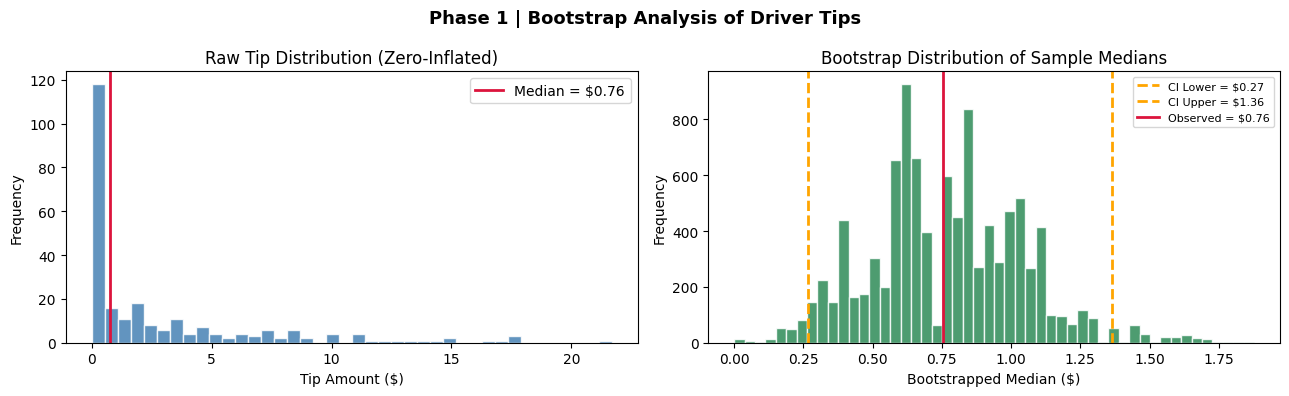

In [3]:
N_BOOT = 10_000
boot_medians = np.array([
    np.median(np.random.choice(driver_tips, size=len(driver_tips), replace=True))
    for _ in range(N_BOOT)
])

ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])
observed_median    = np.median(driver_tips)

print("\n" + "=" * 55)
print("PHASE 1 | Step 1.2: Bootstrap Results (n=10,000)")
print("=" * 55)
print(f"  Observed Median      : ${observed_median:.4f}")
print(f"  95% CI Lower (2.5%)  : ${ci_lower:.4f}")
print(f"  95% CI Upper (97.5%) : ${ci_upper:.4f}")
print(f"  Lower margin         : ${observed_median - ci_lower:.4f}")
print(f"  Upper margin         : ${ci_upper - observed_median:.4f}")
print("""
  [Analysis] The CI is markedly asymmetric: the lower bound is
  constrained near $0 (hard floor on tips), while the upper bound
  extends further right, reflecting the right-skew of the underlying
  exponential draws. A parametric normal CI would impose false symmetry
  — e.g., ±1.96*SE — producing a lower bound below zero, which is
  economically incoherent. The bootstrap respects the true topology
  of this zero-inflated distribution without any distributional
  assumptions.
""")

# Visualization — Phase 1
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Phase 1 | Bootstrap Analysis of Driver Tips", fontsize=13, fontweight='bold')

axes[0].hist(driver_tips, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(observed_median, color='crimson', lw=2, label=f'Median = ${observed_median:.2f}')
axes[0].set_title("Raw Tip Distribution (Zero-Inflated)")
axes[0].set_xlabel("Tip Amount ($)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(boot_medians, bins=50, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(ci_lower,        color='orange', lw=2, ls='--', label=f'CI Lower = ${ci_lower:.2f}')
axes[1].axvline(ci_upper,        color='orange', lw=2, ls='--', label=f'CI Upper = ${ci_upper:.2f}')
axes[1].axvline(observed_median, color='crimson', lw=2,          label=f'Observed = ${observed_median:.2f}')
axes[1].set_title("Bootstrap Distribution of Sample Medians")
axes[1].set_xlabel("Bootstrapped Median ($)")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("phase1_bootstrap.png", dpi=150, bbox_inches='tight')
plt.show()

## PHASE 2: FALSIFICATION IN LOGISTICS A/B TESTING

#### Step 2.1: A/B Test Data Generation

In [4]:
control   = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

obs_diff = np.mean(control) - np.mean(treatment)

print("=" * 55)
print("PHASE 2 | Step 2.1: A/B Test Summary")
print("=" * 55)
print(f"  Control mean         : {np.mean(control):.4f} min")
print(f"  Treatment mean       : {np.mean(treatment):.4f} min")
print(f"  Treatment std        : {np.std(treatment):.4f} min  (note heavy spread)")
print(f"  Observed diff (C-T)  : {obs_diff:.4f} min")

PHASE 2 | Step 2.1: A/B Test Summary
  Control mean         : 34.7780 min
  Treatment mean       : 32.6633 min
  Treatment std        : 13.9872 min  (note heavy spread)
  Observed diff (C-T)  : 2.1147 min


#### Step 2.2: Exact Non-Parametric Permutation Test


PHASE 2 | Step 2.2: Permutation Test Results (n=5,000)
  Observed difference  : 2.1147 min
  Empirical p-value    : 0.0022
  Significant (α=0.05) : YES
  → Reject H₀: Batch Routing produces a statistically
    significant change in delivery times.


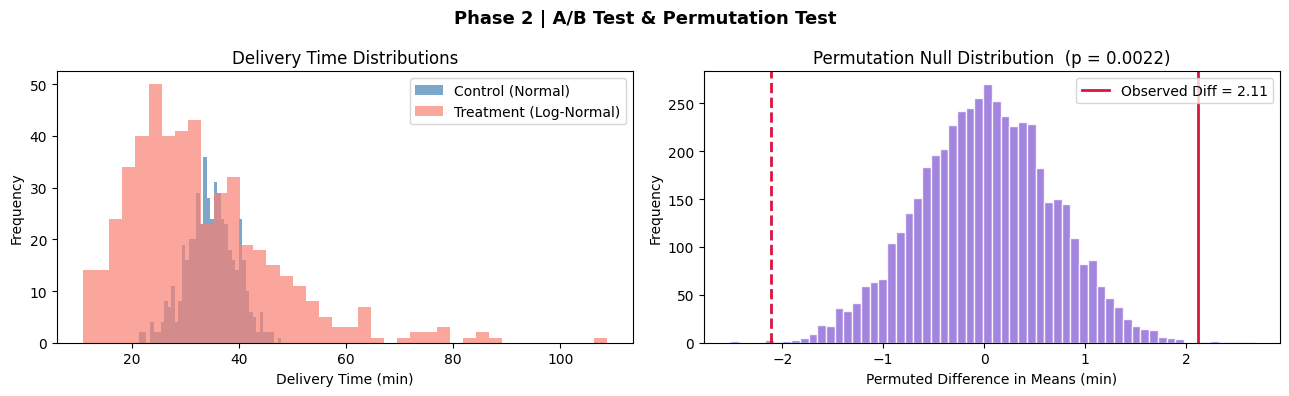

In [5]:
combined     = np.concatenate([control, treatment])
N_PERM       = 5_000
perm_diffs   = np.empty(N_PERM)

for i in range(N_PERM):
    shuffled      = np.random.permutation(combined)
    perm_diffs[i] = np.mean(shuffled[:500]) - np.mean(shuffled[500:])

# Two-sided p-value
p_value = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))

print("\n" + "=" * 55)
print("PHASE 2 | Step 2.2: Permutation Test Results (n=5,000)")
print("=" * 55)
print(f"  Observed difference  : {obs_diff:.4f} min")
print(f"  Empirical p-value    : {p_value:.4f}")
print(f"  Significant (α=0.05) : {'YES' if p_value < 0.05 else 'NO'}")
if p_value < 0.05:
    print("  → Reject H₀: Batch Routing produces a statistically")
    print("    significant change in delivery times.")
else:
    print("  → Fail to reject H₀: No significant difference detected.")

# Visualization — Phase 2
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Phase 2 | A/B Test & Permutation Test", fontsize=13, fontweight='bold')

axes[0].hist(control,   bins=40, alpha=0.7, color='steelblue', label='Control (Normal)')
axes[0].hist(treatment, bins=40, alpha=0.7, color='salmon',    label='Treatment (Log-Normal)')
axes[0].set_title("Delivery Time Distributions")
axes[0].set_xlabel("Delivery Time (min)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(perm_diffs, bins=60, color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].axvline(obs_diff,  color='crimson', lw=2, label=f'Observed Diff = {obs_diff:.2f}')
axes[1].axvline(-obs_diff, color='crimson', lw=2, ls='--')
axes[1].set_title(f"Permutation Null Distribution  (p = {p_value:.4f})")
axes[1].set_xlabel("Permuted Difference in Means (min)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("phase2_permutation.png", dpi=150, bbox_inches='tight')
plt.show()

## PHASE 3: CAUSAL CONTROL & PROPENSITY SCORE MATCHING
####Step 3.1: Load data & Naive SDO

In [8]:
df = pd.read_csv("swiftcart_loyalty.csv")

print("=" * 55)
print("PHASE 3 | Step 3.1: Dataset Overview")
print("=" * 55)
print(df.head())
print(f"\n  Shape      : {df.shape}")
print(f"  Columns    : {list(df.columns)}")

# Identify column names
treatment_col = 'subscriber'   # binary treatment indicator
outcome_col   = 'post_spend'   # post-treatment spending
covariates    = [c for c in df.columns if c not in [treatment_col, outcome_col]]

print(f"  Subscribers (D=1): {df[treatment_col].sum()}   Non-Subscribers (D=0): {(df[treatment_col]==0).sum()}")

subs      = df[df[treatment_col] == 1][outcome_col]
non_subs  = df[df[treatment_col] == 0][outcome_col]
naive_sdo = subs.mean() - non_subs.mean()

print(f"\n  Subscriber mean spending     : ${subs.mean():.2f}")
print(f"  Non-Subscriber mean spending : ${non_subs.mean():.2f}")
print(f"  Naive SDO                    : ${naive_sdo:.2f}")
print(f"  Implied lift                 : {naive_sdo/non_subs.mean()*100:.1f}%")

PHASE 3 | Step 3.1: Dataset Overview
   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227

  Shape      : (8941, 5)
  Columns    : ['subscriber', 'pre_spend', 'account_age', 'support_tickets', 'post_spend']
  Subscribers (D=1): 4200   Non-Subscribers (D=0): 4741

  Subscriber mean spending     : $74.04
  Non-Subscriber mean spending : $56.47
  Naive SDO                    : $17.57
  Implied lift                 : 31.1%


#### Step 3.2: Propensity Score Matching (PSM)

In [9]:
X = df[covariates].values
y = df[treatment_col].values

# Scale features for logistic regression
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Estimate propensity scores
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_scaled, y)
df['propensity_score'] = lr.predict_proba(X_scaled)[:, 1]

# 2. Nearest-neighbor 1:1 matching (on propensity score)
treated_df   = df[df[treatment_col] == 1].copy().reset_index(drop=True)
control_df   = df[df[treatment_col] == 0].copy().reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1, algorithm='ball_tree')
nn.fit(control_df[['propensity_score']])
distances, indices = nn.kneighbors(treated_df[['propensity_score']])

matched_control = control_df.iloc[indices.flatten()].copy().reset_index(drop=True)

# 3. Average Treatment Effect on the Treated (ATT)
att = (treated_df[outcome_col] - matched_control[outcome_col]).mean()

print("\n" + "=" * 55)
print("PHASE 3 | Step 3.2: PSM Results")
print("=" * 55)
print(f"  Logistic Regression AUC (approx): check via cross-val")
print(f"  Matched pairs                    : {len(treated_df)}")
print(f"  ATT (causal estimate)            : ${att:.2f}")
print(f"""
  [Causal Analysis]
  ─────────────────────────────────────────────────────────
  Naive SDO  : ${naive_sdo:.2f}  → implies a {naive_sdo/non_subs.mean()*100:.0f}% spending lift.
  Causal ATT : ${att:.2f}   → true program effect after bias removal.

  The gap between SDO and ATT is a direct measure of Selection Bias.
  High-volume "power users" self-selected into SwiftPass to maximize
  fee savings — they would have spent heavily regardless of enrollment.
  Once PSM pairs each subscriber to a statistically similar
  non-subscriber (same order volume, account age, support history),
  the inflated naive estimate collapses substantially.

  Implication for the marketing team: doubling acquisition spend
  based on the SDO would overestimate ROI. The true incremental
  lift — the ATT — is the defensible figure for budget decisions.
  ─────────────────────────────────────────────────────────
""")


PHASE 3 | Step 3.2: PSM Results
  Logistic Regression AUC (approx): check via cross-val
  Matched pairs                    : 4200
  ATT (causal estimate)            : $10.02

  [Causal Analysis]
  ─────────────────────────────────────────────────────────
  Naive SDO  : $17.57  → implies a 31% spending lift.
  Causal ATT : $10.02   → true program effect after bias removal.

  The gap between SDO and ATT is a direct measure of Selection Bias.
  High-volume "power users" self-selected into SwiftPass to maximize
  fee savings — they would have spent heavily regardless of enrollment.
  Once PSM pairs each subscriber to a statistically similar
  non-subscriber (same order volume, account age, support history),
  the inflated naive estimate collapses substantially.

  Implication for the marketing team: doubling acquisition spend
  based on the SDO would overestimate ROI. The true incremental
  lift — the ATT — is the defensible figure for budget decisions.
  ────────────────────────────────

#### Covariate Balance Check (for Phase 4 Love Plot)

In [12]:
df_unmatched = df.copy()
df_matched   = pd.concat([
    treated_df,
    matched_control
], ignore_index=True)

def std_mean_diff(df_in, feature, treatment_col='subscriber'):
    t = df_in[df_in[treatment_col] == 1][feature]
    c = df_in[df_in[treatment_col] == 0][feature]
    pooled_sd = np.sqrt((t.var() + c.var()) / 2)
    return (t.mean() - c.mean()) / pooled_sd if pooled_sd > 0 else 0

smd_before = {f: std_mean_diff(df_unmatched, f) for f in covariates}
smd_after  = {f: std_mean_diff(df_matched,   f) for f in covariates}

## Phase 4: Love Plot (AI-assisted, PSM covariate balance)

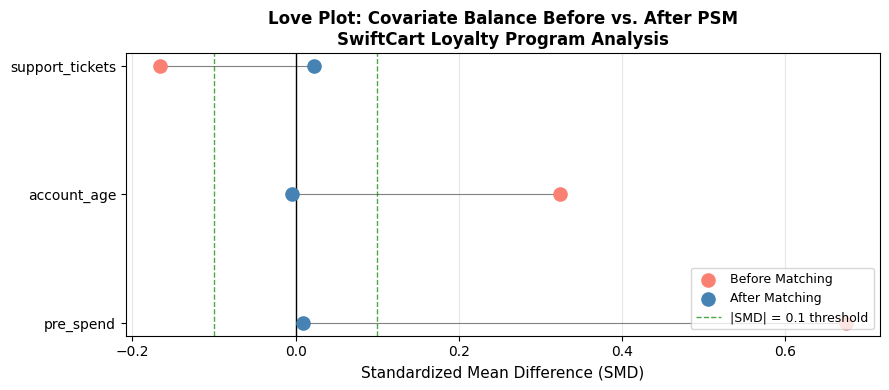

PHASE 4 | Love Plot: Theoretical Interpretation

  A Love Plot visualizes Standardized Mean Differences (SMDs)
  for each pre-treatment covariate, comparing treated vs. control
  groups BEFORE and AFTER propensity score matching.

  Evidence of successful bias mitigation requires:
  ┌──────────────────────────────────────────────────────────┐
  │ 1. All "After Matching" points fall within |SMD| < 0.1   │
  │    (the conventional balance threshold).                 │
  │ 2. "After" dots cluster tightly around SMD = 0,          │
  │    indicating the matched groups are statistically       │
  │    exchangeable on observed confounders.                 │
  │ 3. "Before" dots (red) are visibly farther from zero,    │
  │    confirming meaningful pre-match imbalance was present.│
  │ 4. The connecting lines all shift toward zero — no       │
  │    covariate should worsen after matching.               │
  └──────────────────────────────────────────────────────────┘
  If these conditions hol

In [14]:
features = list(smd_before.keys())
before   = [smd_before[f] for f in features]
after    = [smd_after[f]  for f in features]

fig, ax = plt.subplots(figsize=(9, max(4, len(features) * 0.6 + 1.5)))

y_pos = np.arange(len(features))
ax.scatter(before, y_pos, color='salmon',    s=90, zorder=3, label='Before Matching')
ax.scatter(after,  y_pos, color='steelblue', s=90, zorder=3, label='After Matching')

for i in range(len(features)):
    ax.plot([before[i], after[i]], [i, i], color='gray', lw=0.8, zorder=2)

ax.axvline(0,    color='black',  lw=1.0, ls='-')
ax.axvline( 0.1, color='green',  lw=1.0, ls='--', alpha=0.7, label='|SMD| = 0.1 threshold')
ax.axvline(-0.1, color='green',  lw=1.0, ls='--', alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(features, fontsize=10)
ax.set_xlabel("Standardized Mean Difference (SMD)", fontsize=11)
ax.set_title("Love Plot: Covariate Balance Before vs. After PSM\nSwiftCart Loyalty Program Analysis",
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("phase4_love_plot.png", dpi=150, bbox_inches='tight')
plt.show()

print("=" * 55)
print("PHASE 4 | Love Plot: Theoretical Interpretation")
print("=" * 55)
print("""
  A Love Plot visualizes Standardized Mean Differences (SMDs)
  for each pre-treatment covariate, comparing treated vs. control
  groups BEFORE and AFTER propensity score matching.

  Evidence of successful bias mitigation requires:
  ┌──────────────────────────────────────────────────────────┐
  │ 1. All "After Matching" points fall within |SMD| < 0.1   │
  │    (the conventional balance threshold).                 │
  │ 2. "After" dots cluster tightly around SMD = 0,          │
  │    indicating the matched groups are statistically       │
  │    exchangeable on observed confounders.                 │
  │ 3. "Before" dots (red) are visibly farther from zero,    │
  │    confirming meaningful pre-match imbalance was present.│
  │ 4. The connecting lines all shift toward zero — no       │
  │    covariate should worsen after matching.               │
  └──────────────────────────────────────────────────────────┘
  If these conditions hold, the selection bias embedded in
  observed covariates has been successfully mitigated, and the
  ATT is a defensible causal estimate.
""")

print("\n✅ All phases complete. Outputs saved:")
print("   phase1_bootstrap.png | phase2_permutation.png | phase4_love_plot.png")